# CodeAlpha — Task 1: Credit Scoring Model

**Objective:** Predict an individual's creditworthiness from past financial data.

**Approach:** Classification using Logistic Regression, Decision Tree, and Random Forest, compared on Precision, Recall, F1-Score, and ROC-AUC.

**Pipeline:** Data → EDA → Feature Engineering → Train/Test Split → Scale → Train 3 models → Evaluate → Compare → Feature Importance.

*CodeAlpha Machine Learning Internship.*

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 2. Dataset

We build a realistic **synthetic credit dataset** so the notebook runs anywhere with no download. The features mirror what a real credit file contains: income, debt, payment history, credit utilization, age, employment length, and number of open accounts.

> To use a real dataset instead (e.g. the German Credit / UCI dataset), just load it into a DataFrame named `df` with a binary target column `creditworthy` and the rest of the notebook works unchanged.

In [2]:
n = 3000

income          = np.random.normal(55000, 20000, n).clip(12000, 200000)
debt            = np.random.normal(15000, 12000, n).clip(0, 120000)
payment_history = np.random.uniform(0, 1, n)        # fraction of on-time payments
credit_util     = np.random.uniform(0, 1, n)        # balance / credit limit
age             = np.random.normal(40, 12, n).clip(18, 80).astype(int)
emp_length      = np.random.exponential(6, n).clip(0, 40)
open_accounts   = np.random.poisson(4, n).clip(0, 20)

# Latent "true" creditworthiness signal + noise -> binary label
score = (
    0.000020 * income
    - 0.000030 * debt
    + 2.5 * payment_history
    - 1.8 * credit_util
    + 0.010 * age
    + 0.05 * emp_length
    - 0.03 * open_accounts
)
score += np.random.normal(0, 0.4, n)
prob = 1 / (1 + np.exp(-(score - score.mean())))
creditworthy = (prob > 0.5).astype(int)

df = pd.DataFrame({
    "income": income.round(0),
    "debt": debt.round(0),
    "payment_history": payment_history.round(3),
    "credit_utilization": credit_util.round(3),
    "age": age,
    "employment_length": emp_length.round(1),
    "open_accounts": open_accounts,
    "creditworthy": creditworthy,
})
print(df.shape)
df.head()

(3000, 8)


,income,debt,payment_history,credit_utilization,age,employment_length,open_accounts,creditworthy
0,64934.0,0.0,0.336,0.748,35,2.1,6,0
1,52235.0,4675.0,0.211,0.869,22,4.0,6,0
2,67954.0,10037.0,0.313,0.537,51,0.7,7,0
3,85461.0,37652.0,0.179,0.752,41,3.8,1,0
4,50317.0,21679.0,0.902,0.140,30,1.7,6,1


## 3. Exploratory Data Analysis

In [3]:
print(df.info())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   income              3000 non-null   float64
 1   debt                3000 non-null   float64
 2   payment_history     3000 non-null   float64
 3   credit_utilization  3000 non-null   float64
 4   age                 3000 non-null   int64  
 5   employment_length   3000 non-null   float64
 6   open_accounts       3000 non-null   int64  
 7   creditworthy        3000 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 187.6 KB
None


,income,debt,payment_history,credit_utilization,age,employment_length,open_accounts,creditworthy
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,55737.958667,15244.822333,0.492691,0.498999,39.849667,6.181367,4.020667,0.499667
std,19488.249958,10881.831028,0.284294,0.291008,11.568968,6.193478,1.985503,0.500083
min,12000.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000
25%,42449.500000,6449.000000,0.252000,0.244000,32.000000,1.900000,3.000000,0.000000
50%,55487.000000,14732.500000,0.491500,0.490000,40.000000,4.200000,4.000000,0.000000
75%,68472.000000,22664.000000,0.733000,0.756000,48.000000,8.325000,5.000000,1.000000
max,133525.000000,53917.000000,1.000000,1.000000,80.000000,40.000000,13.000000,1.000000


Class balance (1 = creditworthy, 0 = not):
creditworthy
0    0.5
1    0.5
Name: proportion, dtype: float64


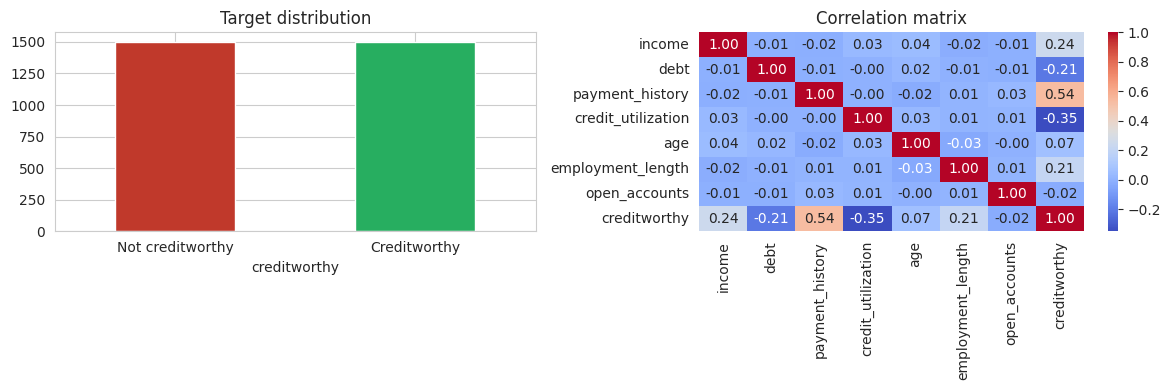

In [4]:
print("Class balance (1 = creditworthy, 0 = not):")
print(df['creditworthy'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['creditworthy'].value_counts().plot(kind='bar', ax=ax[0], color=['#c0392b', '#27ae60'])
ax[0].set_title("Target distribution"); ax[0].set_xticklabels(['Not creditworthy', 'Creditworthy'], rotation=0)

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', ax=ax[1])
ax[1].set_title("Correlation matrix")
plt.tight_layout(); plt.show()

## 4. Feature Engineering

We add two ratios that lenders care about more than the raw numbers:
- **debt-to-income (DTI):** debt relative to income — a core lending metric.
- **income per open account:** spreads income across active credit lines.

In [5]:
df['debt_to_income'] = (df['debt'] / df['income']).round(3)
df['income_per_account'] = (df['income'] / (df['open_accounts'] + 1)).round(0)

features = ['income', 'debt', 'payment_history', 'credit_utilization', 'age',
            'employment_length', 'open_accounts', 'debt_to_income', 'income_per_account']
target = 'creditworthy'

X = df[features]
y = df[target]
print("Features:", features)

Features: ['income', 'debt', 'payment_history', 'credit_utilization', 'age', 'employment_length', 'open_accounts', 'debt_to_income', 'income_per_account']


## 5. Train/Test Split + Scaling

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 2400 rows | Test: 600 rows


## 6. Train Three Models

Tree-based models don't need scaling, but logistic regression does — so we feed scaled
data to logistic regression and raw data to the tree models.

In [7]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), True),
    "Decision Tree":       (DecisionTreeClassifier(max_depth=6, random_state=42), False),
    "Random Forest":       (RandomForestClassifier(n_estimators=200, random_state=42), False),
}

results = {}
for name, (model, use_scaled) in models.items():
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s  if use_scaled else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    results[name] = {
        "model": model, "Xte": Xte, "y_pred": y_pred, "y_proba": y_proba,
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    }
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.


Random Forest trained.


## 7. Evaluation — Metrics Comparison

In [8]:
metrics_df = pd.DataFrame({
    name: {k: round(v, 3) for k, v in r.items()
           if k in ['Precision', 'Recall', 'F1', 'ROC-AUC']}
    for name, r in results.items()
}).T
print(metrics_df)
metrics_df

                     Precision  Recall     F1  ROC-AUC
Logistic Regression      0.873   0.890  0.881    0.951
Decision Tree            0.812   0.820  0.816    0.885
Random Forest            0.837   0.857  0.847    0.933


,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.873,0.890,0.881,0.951
Decision Tree,0.812,0.820,0.816,0.885
Random Forest,0.837,0.857,0.847,0.933


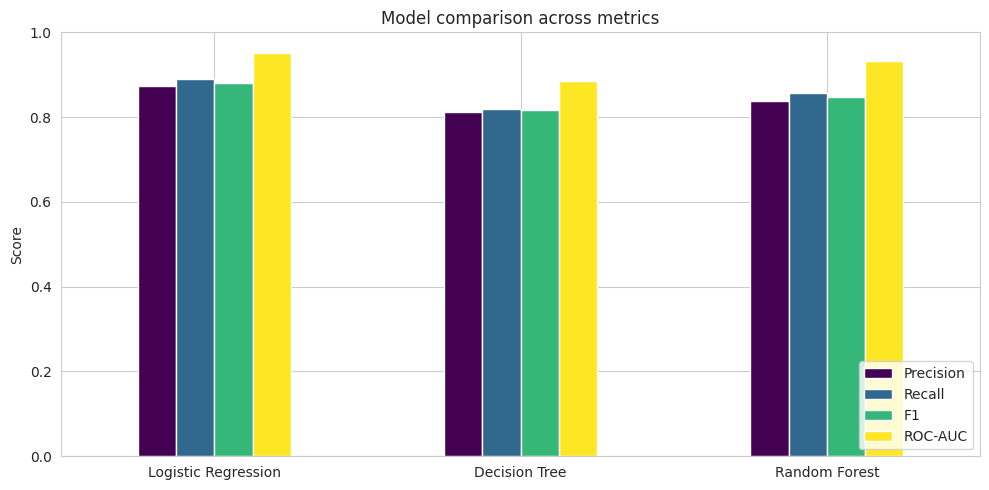

In [9]:
metrics_df.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title("Model comparison across metrics")
plt.ylabel("Score"); plt.ylim(0, 1); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 8. Confusion Matrix + Classification Report (best model)

Best model by F1: Logistic Regression

                  precision    recall  f1-score   support

Not creditworthy       0.89      0.87      0.88       300
    Creditworthy       0.87      0.89      0.88       300

        accuracy                           0.88       600
       macro avg       0.88      0.88      0.88       600
    weighted avg       0.88      0.88      0.88       600



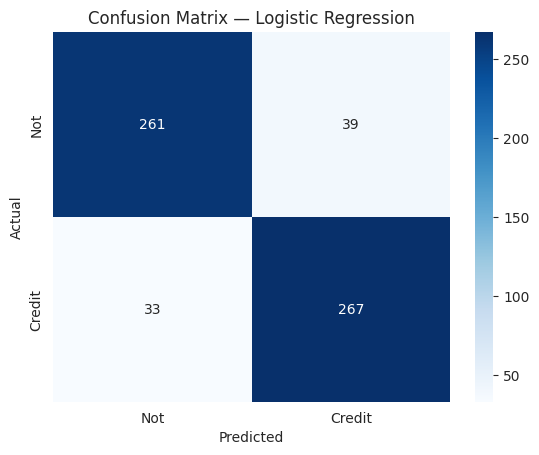

In [10]:
best_name = metrics_df['F1'].idxmax()
best = results[best_name]
print(f"Best model by F1: {best_name}\n")
print(classification_report(y_test, best['y_pred'],
      target_names=['Not creditworthy', 'Creditworthy']))

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not', 'Credit'], yticklabels=['Not', 'Credit'])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted"); plt.show()

## 9. ROC Curves

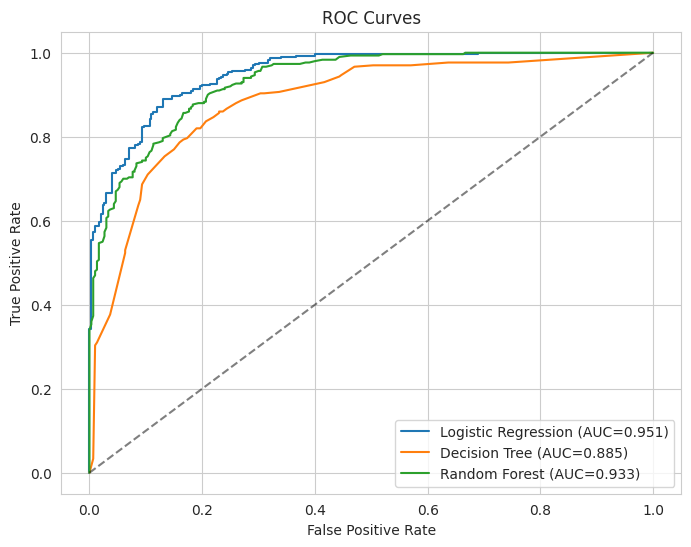

In [11]:
plt.figure(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(loc='lower right'); plt.show()

## 10. Feature Importance (Random Forest)

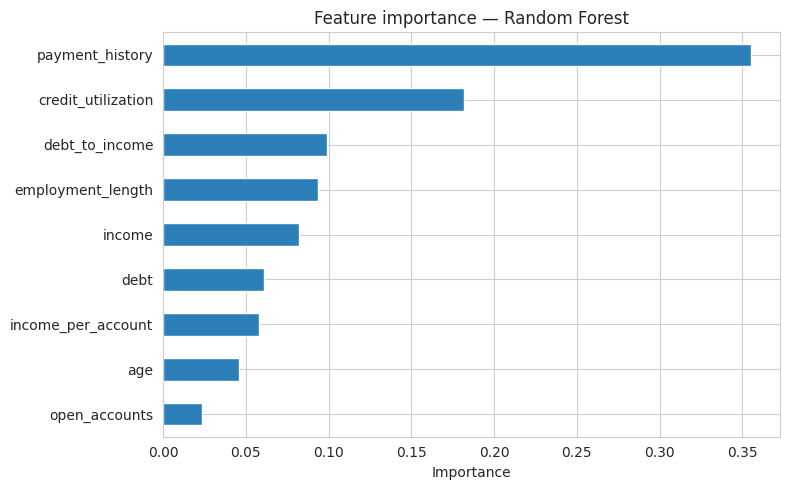

payment_history       0.355
credit_utilization    0.182
debt_to_income        0.099
employment_length     0.094
income                0.082
debt                  0.061
income_per_account    0.058
age                   0.046
open_accounts         0.024
dtype: float64


In [12]:
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.plot(kind='barh', figsize=(8, 5), color='#2c7fb8')
plt.title("Feature importance — Random Forest")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3))

## 11. Conclusion

We built a credit scoring classifier comparing three algorithms on the same financial features. Each was evaluated with **Precision, Recall, F1-Score, and ROC-AUC** — the metrics that matter for credit decisions, where both false approvals and false rejections are costly.

The strongest features — payment history, credit utilization, and debt-to-income — match what real lenders weigh most heavily, which is a good sanity check that the model learned sensible patterns.

**Next steps:** hyperparameter tuning (GridSearchCV), cross-validation, and threshold adjustment to trade off precision vs recall for the business case.

*Task 1 complete — CodeAlpha Machine Learning Internship.*